Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Adjusted Label distribution:
 Consensus_Label
0    105
1      6
Name: count, dtype: int64

=== Anomaly Analysis ===
Total Anomalies: 6
Anomaly Percentage: 5.41%


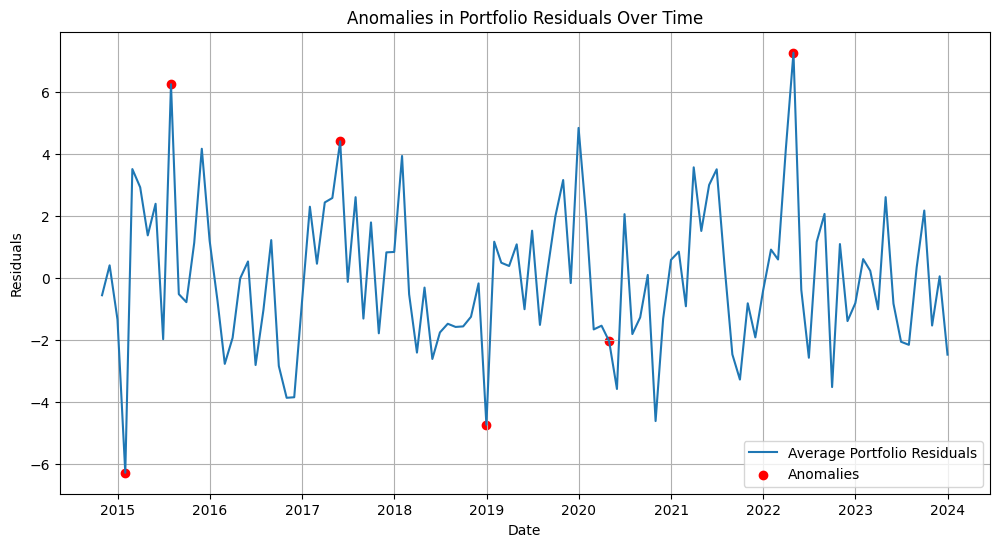

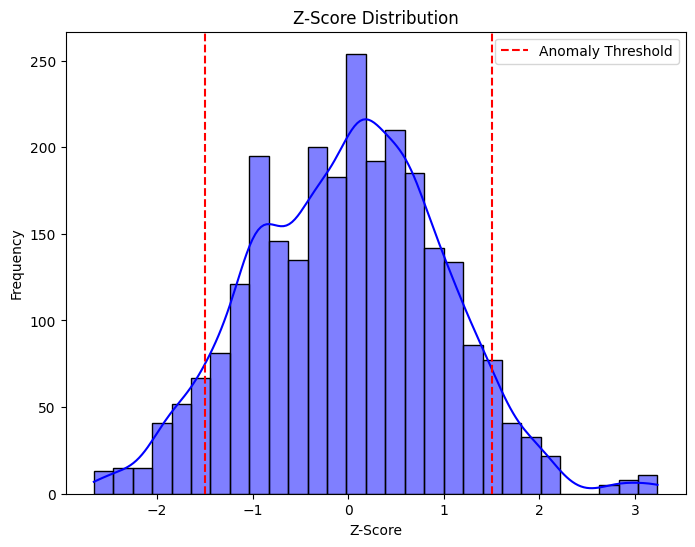

In [21]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn statsmodels imbalanced-learn

from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm

# ====================================
# Step 1: Data Loading and Preprocessing
# ====================================
# Set up file paths
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'DatasetsCombinedCommonPeriodMatrix.xlsx')

# Function to load the dataset
def load_data(file_path):
    try:
        data = pd.read_excel(file_path, sheet_name="DatasetsCombinedCommonPeriodMat", index_col=0)
        data.index = pd.to_datetime(data.index, errors='coerce')
        portfolio_returns = data.filter(like='.PortfolioReturnMatrix')
        benchmark_returns = data.filter(like='.BenchmarkReturnMatrix')
        index_data = data.filter(like='.OutperformanceMatrix')
        return {
            "PortfolioReturnMatrix": portfolio_returns,
            "BenchmarkReturnMatrix": benchmark_returns,
            "IndexData": index_data
        }
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# ====================================
# Step 2: Regression to Generate Residuals
# ====================================
def factorize_regression(common_period_matrix):
    portfolio_returns = common_period_matrix['PortfolioReturnMatrix']
    index_data = common_period_matrix['IndexData']
    index_data = index_data.loc[portfolio_returns.index]
    residuals_df = pd.DataFrame(index=portfolio_returns.index)
    for col in portfolio_returns.columns:
        mandate_returns = portfolio_returns[col]
        X = sm.add_constant(index_data)
        y = mandate_returns
        if y.isna().all() or X.isna().all().any():
            print(f"Skipping regression for {col} due to insufficient data.")
            continue
        model = sm.OLS(y, X, missing='drop')
        regression_result = model.fit()
        residuals_df[col] = regression_result.resid
    return residuals_df

# ====================================
# Step 3: Labeling Anomalies
# ====================================
def label_anomalies(residuals, threshold=1.5):
    z_scores = (residuals - residuals.mean()) / residuals.std()
    anomalies = (np.abs(z_scores) > threshold).astype(int)
    return anomalies

# ====================================
# Step 4: Analyzing Anomalies
# ====================================
def analyze_anomalies(data, labels, feature="Consensus_Label"):
    """
    Analyze anomalies by their occurrence and impact on key metrics.

    Parameters:
    data (pd.DataFrame): Residuals DataFrame.
    labels (pd.DataFrame): Binary labels indicating anomalies.
    feature (str): The column name for anomaly labels.
    """
    print("\n=== Anomaly Analysis ===")

    # Count anomalies
    total_anomalies = labels[feature].sum()
    print(f"Total Anomalies: {total_anomalies}")

    # Occurrence percentage
    anomaly_percentage = (total_anomalies / len(labels)) * 100
    print(f"Anomaly Percentage: {anomaly_percentage:.2f}%")

    # Visualize anomaly occurrences over time
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data.mean(axis=1), label="Average Portfolio Residuals")
    plt.scatter(
        data.index[labels[feature] == 1],
        data.mean(axis=1)[labels[feature] == 1],
        color="red", label="Anomalies"
    )
    plt.title("Anomalies in Portfolio Residuals Over Time")
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot Z-score distribution
    z_scores = (data - data.mean()) / data.std()
    plt.figure(figsize=(8, 6))
    sns.histplot(z_scores.values.flatten(), kde=True, color="blue")
    plt.axvline(x=1.5, color="red", linestyle="--", label="Anomaly Threshold")
    plt.axvline(x=-1.5, color="red", linestyle="--")
    plt.title("Z-Score Distribution")
    plt.xlabel("Z-Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# ====================================
# Main Execution Block
# ====================================
if __name__ == "__main__":
    # Load data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Step 1: Generate residuals via regression
        residuals = factorize_regression(data_matrices)

        # Step 2: Label anomalies using Z-scores
        threshold = 1.5
        anomaly_labels = label_anomalies(residuals, threshold=threshold)

        # Combine residuals and labels
        combined_data = residuals.copy()
        combined_data["Consensus_Label"] = anomaly_labels.mean(axis=1).round().astype(int)

        # Check label distribution
        print("Adjusted Label distribution:\n", combined_data["Consensus_Label"].value_counts())

        # Step 4: Analyze Anomalies
        analyze_anomalies(data=residuals, labels=combined_data, feature="Consensus_Label")
    else:
        print("Failed to load the data.")


In [22]:
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred))

if len(rf_model.classes_) > 1:
    print("AUC-ROC:", roc_auc_score(y_test, y_prob))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.33      1.00      0.50         1

    accuracy                           0.91        23
   macro avg       0.67      0.95      0.73        23
weighted avg       0.97      0.91      0.93        23

AUC-ROC: 0.9090909090909091


In [23]:
for threshold in [1.0, 1.5, 2.0]:
    anomaly_labels = label_anomalies(residuals, threshold=threshold)
    print(f"Threshold {threshold}:")
    print(anomaly_labels.mean(axis=1).value_counts())


Threshold 1.0:
0.000000    40
0.500000    20
0.333333     8
1.000000     7
0.958333     4
0.041667     4
0.291667     4
0.208333     4
0.250000     3
0.458333     3
0.541667     2
0.666667     2
0.166667     2
0.833333     2
0.791667     2
0.083333     1
0.583333     1
0.750000     1
0.416667     1
Name: count, dtype: int64
Threshold 1.5:
0.000000    75
0.500000    11
0.041667     6
0.208333     4
0.166667     4
0.333333     2
0.291667     2
0.666667     2
1.000000     1
0.958333     1
0.458333     1
0.750000     1
0.583333     1
Name: count, dtype: int64
Threshold 2.0:
0.000000    97
0.041667     4
0.500000     3
0.208333     3
0.458333     2
0.541667     1
0.333333     1
Name: count, dtype: int64


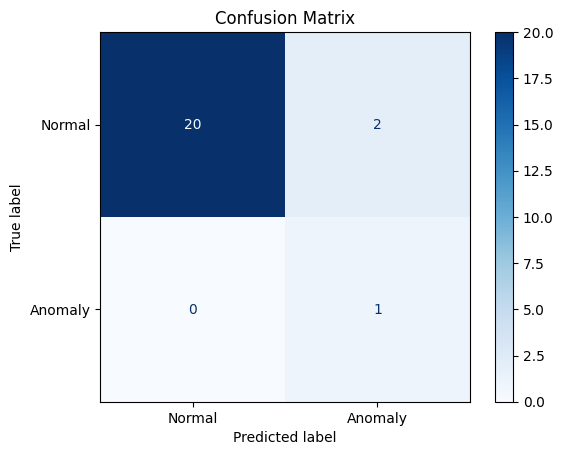

False Positives:
                     Valora PK - Aktien Schweiz Small and Mid Caps (Pictet).PortfolioReturnMatrix  \
Date                                                                                                
2016-11-30 12:00:00                                          -8.488250                              
2020-06-30 12:00:00                                          -0.728402                              

                     CPEG GenÃ¨ve - Actions suisses S/M Cap (a) (GAM).PortfolioReturnMatrix  \
Date                                                                                          
2016-11-30 12:00:00                                          -8.193084                        
2020-06-30 12:00:00                                           0.937381                        

                     PVST Adval Tech - SaraSelect (VV).PortfolioReturnMatrix  \
Date                                                                           
2016-11-30 12:00:00                  

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


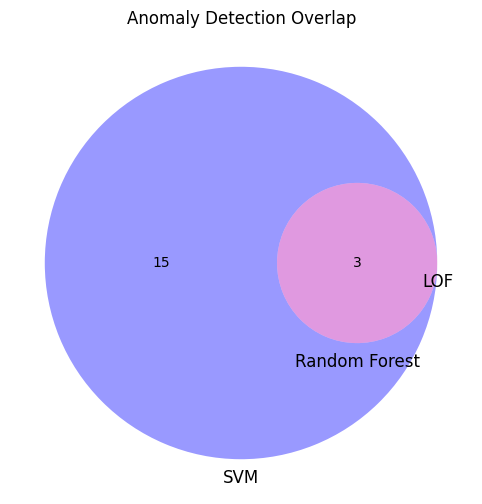